In [1]:
import pandas as pd
import numpy as np 
import matplotlib as plt
import seaborn as sns 
import matplotlib.pyplot as plt


In [2]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv('Cardiovascular_Disease.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df['age'] = df['age'] // 365

In [5]:
data = df[(df['height'].between(150,200)) & (df['weight'].between (45,120)) &(df['ap_hi'].between (100,200)) &(df['ap_lo'].between (50,90))]

<Axes: >

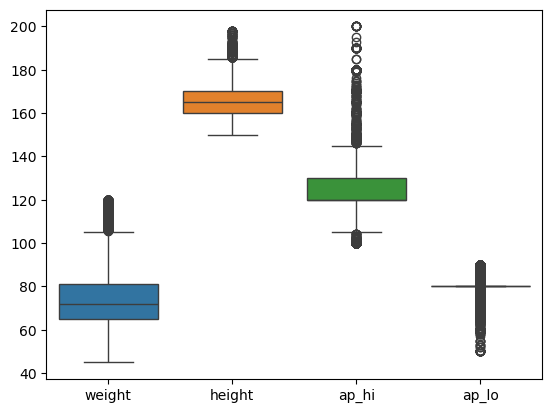

In [6]:
sns.boxplot(data=data[['weight', 'height', 'ap_hi','ap_lo']])

In [7]:
data = data.drop( columns = 'id')

In [8]:
data.corr()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age,1.000000,-0.026796,-0.081190,0.060249,0.206157,0.149013,0.149866,0.095122,-0.049144,-0.031378,-0.011903,0.242939
gender,-0.026796,1.000000,0.514697,0.150005,0.046568,0.052281,-0.040553,-0.025325,0.337123,0.166348,0.006947,-0.003164
height,-0.081190,0.514697,1.000000,0.298474,0.008691,0.031638,-0.057844,-0.025496,0.191687,0.093422,-0.008459,-0.019166
weight,0.060249,0.150005,0.298474,1.000000,0.227661,0.200668,0.134777,0.093880,0.065472,0.061306,-0.015596,0.162259
ap_hi,0.206157,0.046568,0.008691,0.227661,1.000000,0.613052,0.181767,0.083907,0.023804,0.021605,-0.001012,0.412470
ap_lo,0.149013,0.052281,0.031638,0.200668,0.613052,1.000000,0.134105,0.058374,0.016908,0.021753,-0.001082,0.292182
cholesterol,0.149866,-0.040553,-0.057844,0.134777,0.181767,0.134105,1.000000,0.452842,0.008251,0.026303,0.006909,0.221414
gluc,0.095122,-0.025325,-0.025496,0.093880,0.083907,0.058374,0.452842,1.000000,-0.006882,0.004160,-0.008490,0.086792
smoke,-0.049144,0.337123,0.191687,0.065472,0.023804,0.016908,0.008251,-0.006882,1.000000,0.346050,0.027910,-0.022810
alco,-0.031378,0.166348,0.093422,0.061306,0.021605,0.021753,0.026303,0.004160,0.346050,1.000000,0.025722,-0.019356


<Axes: >

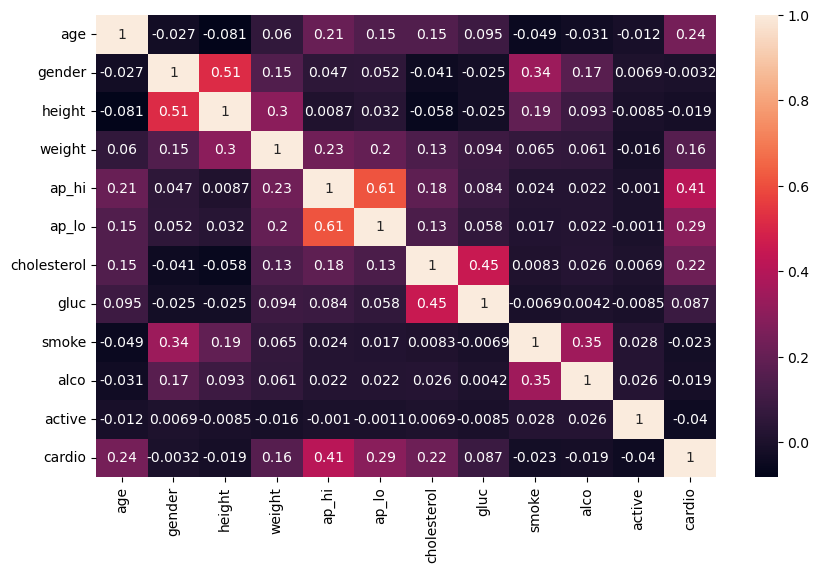

In [9]:
cor = data.corr()
plt.figure(figsize = (10,6))
sns.heatmap(cor, annot = True)

In [10]:
data.columns


Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [11]:
feature = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active'] 
target = 'cardio'

In [12]:
X= data[feature]
Y= data[target]

In [13]:
X_train, X_test,Y_train, Y_test = train_test_split(
    X,Y, test_size=0.2, random_state= 42
    

)

In [14]:
scaler = StandardScaler()

In [15]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [ ]:
model = SVC(kernel = 'linear', gamma =1, C=1)

In [ ]:
model.fit(X_train_scale, Y_train)

In [ ]:
Y_pred= model.predict(X_test_scale)

In [ ]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)


In [ ]:
print(cm)